# Run the eval suite

Drives the functions in `src/eval/*.py` on the live net + your trained SAE.

- **Correlational** — per square-token, does a feature's firing match a ground-truth `board_properties` label? Scored by F1 via `correlational.best_feature_for_property`.
- **Eyeball** — render the winning feature's top-activating boards (`viz.show_top_activations`).
- **Causal** — ablate a candidate feature with `causal.patch_feature` and check Leela's policy/WDL heads actually move.

In [34]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
import yaml
from pathlib import Path

import chess
import torch
from lczerolens import LczeroBoard

from src import hook
from src.data import positions
from src.eval import correlational, causal, feature_mining
from src.eval.board_props import board_properties
from src.viz.features import token_to_square, show_top_activations

cfg = yaml.safe_load(Path("../configs/default.yaml").read_text())   # notebook runs from scripts/

base_model = hook.load_model().eval()
device = next(base_model.parameters()).device
module = hook.list_residual_modules(base_model)[cfg["residual_modual"]]   # same site you trained on
# Whole TopKSAE was saved via torch.save(sae, ...); weights_only=False to unpickle the module.
sae = torch.load(Path("../", cfg["output_path"], "sae.pt"), weights_only=False).eval().to(device)

# Held-out positions (same load + seed as 02), capped small so it's a quick pass.
fens = positions.load_fens(limit=20_000, shuffle=True, seed=cfg["seed"])
eval_fens = fens[int(0.9 * len(fens)):][:300]
print(module, "| positions:", len(eval_fens), "| F:", sae.encoder.out_features, "| device:", device)

module.encoder7/ln2 | positions: 300 | F: 6144 | device: cuda:0


## 1. Correlational (per-token)
Each board has 64 square-tokens. Stack their SAE features into `(N*64, F)` and compare against `board_properties` labels — the per-square keys (`e4_white_pawn`, `e4_occupied`) read off via `token_to_square` (mirrors the board for black to move).

In [36]:
# A feature "fires" on a token only when its activation clears this threshold.
# TopKSAE activations are >=0, so 0.0 == "is in the top-k at all"; raise it to demand a
# stronger, more confident activation before counting the feature as on (trades recall for precision).
FIRE_THRESH = 0.1

# Per-token feature firing across all boards -> (N*64, F) bool (cache.py layout: board r//64, square r%64).
feats_per_board = []
with torch.no_grad():
    for fen in eval_fens:
        feats, _ = sae.encode(hook.get_residual_stream(base_model, fen, module))  # (64, F)
        feats_per_board.append(feats)
fires = torch.cat(feats_per_board) > FIRE_THRESH                                  # (N*64, F) bool

# Ground truth: board_properties gives per-square keys; token_to_square maps each token to its real square.
props = [board_properties(LczeroBoard(fen)) for fen in eval_fens]
sq_names = [[chess.square_name(token_to_square(fen, t)) for t in range(64)] for fen in eval_fens]

/home/cowifornia/code/leela-sae/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  x = x[pos_axes_slices]


In [37]:
# Per-square property families that board_properties defines on every square (skip the per-board scalars).
families = ["occupied"] + [f"{c}_{p}" for c in ("own", "enemy")
                           for p in ("pawn", "knight", "bishop", "rook", "queen", "king")]

ranked = []
for fam in families:
    labels = torch.tensor(
        [props[i][f"{sq_names[i][t]}_{fam}"] for i in range(len(eval_fens)) for t in range(64)],
        dtype=torch.bool,
        device=fires.device,
    )                                                                            # (N*64,)
    feat, f1 = correlational.best_feature_for_property(fires, labels)
    ranked.append((fam, feat, f1))
ranked.sort(key=lambda r: r[2], reverse=True)

for fam, feat, f1 in ranked:
    print(f"f1: {f1:5.3f}  feature {feat:5d}  <-  square is {fam}")

f1: 0.993  feature  1834  <-  square is own_king
f1: 0.992  feature  4765  <-  square is enemy_king
f1: 0.991  feature  2940  <-  square is enemy_pawn
f1: 0.990  feature  4993  <-  square is enemy_rook
f1: 0.980  feature  2988  <-  square is own_rook
f1: 0.976  feature  6107  <-  square is own_knight
f1: 0.975  feature  2006  <-  square is own_queen
f1: 0.972  feature  1140  <-  square is own_bishop
f1: 0.968  feature  5225  <-  square is enemy_bishop
f1: 0.964  feature  4818  <-  square is enemy_knight
f1: 0.939  feature  2550  <-  square is enemy_queen
f1: 0.800  feature   528  <-  square is own_pawn
f1: 0.398  feature  2940  <-  square is occupied


### Hand-written board-level props (per-board firing)
The dozen hand-written properties (`is_check`, castling rights, `white_king_on_g1`, …) are facts about the *whole board*, not a single square — there's no token to pin them to. So firing collapses the 64 tokens too: a feature "fires on this board" if it cleared `FIRE_THRESH` on **any** of that board's square-tokens. Then one label per board, same `best_feature_for_property` F1.

In [38]:
# Per-BOARD firing: did the feature clear FIRE_THRESH on ANY of the 64 tokens of each board?
# (N*64, F) -> (N, 64, F) -> any over the token axis -> (N, F) bool. Same cache.py layout (board r//64).
fires_per_board = fires.view(len(eval_fens), 64, -1).any(dim=1)                   # (N, F) bool

# Only the BOOLEAN hand-written props. The int-valued ones (own_king_square, *_queen_count,
# material_diff, ...) are skipped: F1 needs a binary label, so they'd each need a threshold first.
board_level = [
    "is_check",
    "own_king_castled_kingside",
    "own_can_castle_kingside", "enemy_can_castle_kingside",
    "en_passant_available",
    "e4_occupied_by_own_pawn",
]

ranked_board = []
for key in board_level:
    # One label per board (not per token): props[i][key] is already a per-board bool.
    labels = torch.tensor([props[i][key] for i in range(len(eval_fens))],
                          dtype=torch.bool, device=fires.device)                  # (N,)
    feat, f1 = correlational.best_feature_for_property(fires_per_board, labels)
    ranked_board.append((key, feat, f1))
ranked_board.sort(key=lambda r: r[2], reverse=True)

for key, feat, f1 in ranked_board:
    print(f"f1: {f1:5.3f}  feature {feat:5d}  <-  {key}")

f1: 1.000  feature  2975  <-  en_passant_available
f1: 0.783  feature  5495  <-  own_can_castle_kingside
f1: 0.765  feature  2697  <-  enemy_can_castle_kingside
f1: 0.427  feature  1626  <-  e4_occupied_by_own_pawn
f1: 0.400  feature   685  <-  own_king_castled_kingside
f1: 0.364  feature  3642  <-  is_check


### Eyeball the winning feature
Render the top-activating positions for the best feature of a chosen property, so you can *see* whether its firing squares match the concept (same `mine_feature` -> `show_top_activations` flow as `eyeball_features.ipynb`).

In [39]:
# Pick a property's best feature (default: the top-ranked one) and render where it fires.
fam, feat, _ = ranked[1]   # or set `feat = <index>` by hand to inspect any feature
print(f"feature {feat}  <-  square is {fam}")
results = feature_mining.mine_feature(base_model, eval_fens, sae, module, feat, k=20)
# relative=True: orient each board from the SIDE TO MOVE and label own/enemy, not white/black.
# Leela works in side-to-move coords, so an us/them feature otherwise looks like it fires on BOTH
# colours (e.g. 2940 hits black_pawn at white-to-move AND white_pawn at black-to-move).
show_top_activations(feat, results, relative=True)

feature 4765  <-  square is enemy_king


## 2. Causal
Sanity-check the harness (`scale=1.0` = no-op, heads must not move), then ablate the top candidate and compare to a random control feature.

In [40]:
# No-op: scale=1.0 rewrites the feature to itself -> deltas must be ~0 (else the harness is broken).
pd_, wd_ = causal.patch_feature(base_model, sae, LczeroBoard(), feature_idx=0, layer=module, scale=1.0)
print(f"no-op   policy Δmax={float(pd_.max()):.2e}   wdl Δmax={float(wd_.max()):.2e}   (≈0)")

no-op   policy Δmax=0.00e+00   wdl Δmax=0.00e+00   (≈0)


In [41]:
# Ablate the top correlational candidate on a board where that square-property occurs, vs a random control.
fam, feat, _ = ranked[6]
fen = next(f for f, p in zip(eval_fens, props)
           if any(p[f"{chess.square_name(s)}_{fam}"] for s in chess.SQUARES))
board = LczeroBoard(fen)
control = torch.randint(0, sae.encoder.out_features, (1,)).item()

for label, idx in ((f"{fam} (feat {feat})", feat), (f"control (feat {control})", control)):
    p_delta, w_delta = causal.patch_feature(base_model, sae, board, idx, layer=module, scale=0.0)
    print(f"{label:28s}  policy Δmax={float(p_delta.max()):.3f}   wdl Δmax={float(w_delta.max()):.3f}")

own_queen (feat 2006)         policy Δmax=0.568   wdl Δmax=0.014
control (feat 4135)           policy Δmax=0.000   wdl Δmax=0.000


### Causal effect across features — bar graph
Ablate each candidate feature (`scale=0.0`) on a board that actually exhibits its concept, and plot how far Leela's heads move. Two groups: the **high-F1 correlational** per-square features (§1) and the **hand-coded board-level** props. A random feature is included as a control — a real feature should clear it.

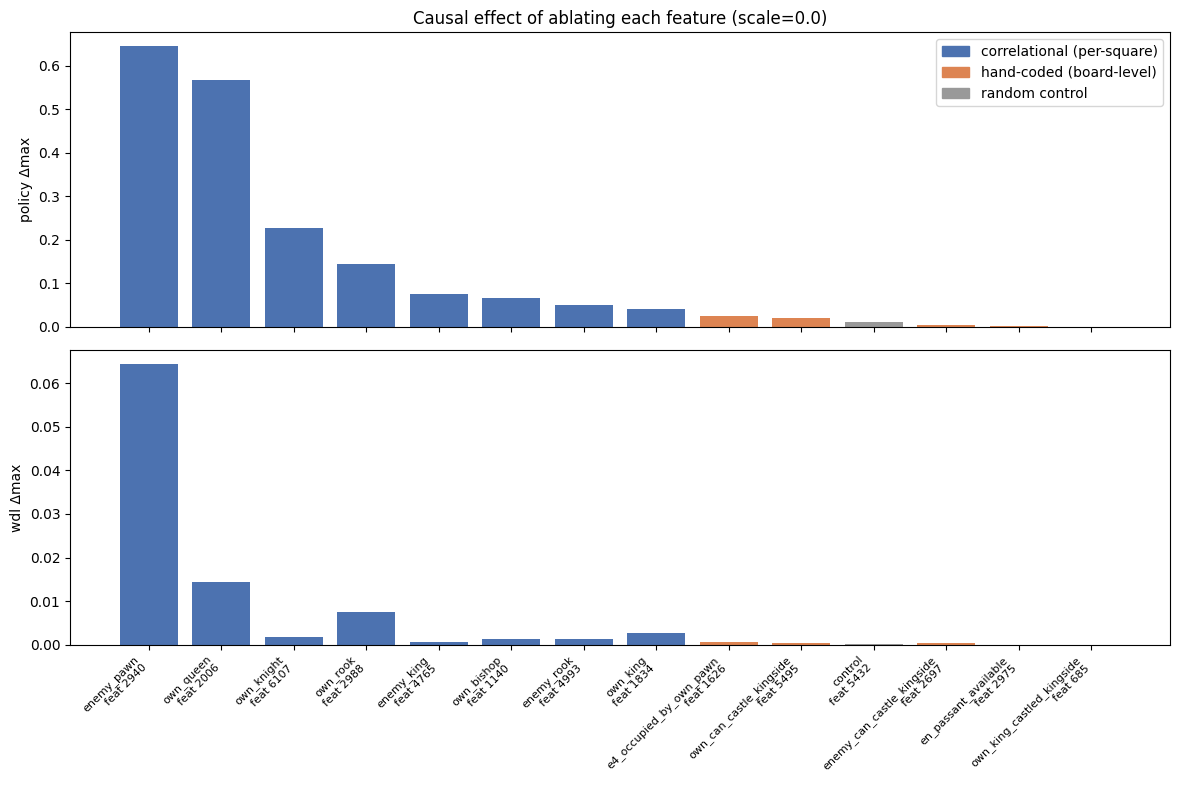

In [42]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Build the candidate list. Each entry: (label, feature_idx, f1, kind, has_concept).
# has_concept(i) -> True if eval board i exhibits the concept, so we ablate on a board where it's present.
def square_has(fam):    # per-square family: any of the 64 squares carries this property
    return lambda i: any(props[i][f"{sq_names[i][t]}_{fam}"] for t in range(64))
def board_has(key):     # hand-coded board-level prop: a single per-board bool
    return lambda i: bool(props[i][key])

candidates  = [(fam, feat, f1, "square", square_has(fam)) for fam, feat, f1 in ranked[:8]]
candidates += [(key, feat, f1, "board",  board_has(key))  for key, feat, f1 in ranked_board[:5]]
# Control: a random feature ablated on the very first board (any board works for a control).
control = torch.randint(0, sae.encoder.out_features, (1,)).item()
candidates.append(("control", control, float("nan"), "control", lambda i: True))

# One ablation per candidate; record the max head shift. Skip concepts absent from the eval set.
records = []
for label, feat, f1, kind, has_concept in candidates:
    idx = next((i for i in range(len(eval_fens)) if has_concept(i)), None)
    if idx is None:
        print(f"skip {label}: no eval board exhibits this concept")
        continue
    p_delta, w_delta = causal.patch_feature(base_model, sae, LczeroBoard(eval_fens[idx]),
                                            feat, layer=module, scale=0.0)
    records.append((label, feat, kind, f1, float(p_delta.max()), float(w_delta.max())))

records.sort(key=lambda r: r[4], reverse=True)   # biggest policy mover first

# Plot: policy Δmax (top) and wdl Δmax (bottom), bars colour-coded by group.
names   = [f"{lab}\nfeat {ft}" for lab, ft, *_ in records]
pol     = [r[4] for r in records]
wdl     = [r[5] for r in records]
palette = {"square": "#4C72B0", "board": "#DD8452", "control": "#999999"}
colors  = [palette[r[2]] for r in records]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(8, len(records) * 0.85), 8), sharex=True)
ax1.bar(range(len(records)), pol, color=colors)
ax1.set_ylabel("policy Δmax")
ax1.set_title("Causal effect of ablating each feature (scale=0.0)")
ax2.bar(range(len(records)), wdl, color=colors)
ax2.set_ylabel("wdl Δmax")
ax2.set_xticks(range(len(records)))
ax2.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax1.legend(handles=[Patch(color=palette["square"],  label="correlational (per-square)"),
                    Patch(color=palette["board"],   label="hand-coded (board-level)"),
                    Patch(color=palette["control"], label="random control")])
plt.tight_layout()
plt.show()